# Fitting a time-averaged spectrum

This notebook shows how to fit a time-averaged X-ray spectrum in nDspec. For least-chi squares fitting, nDspec makes use of the [lmfit library](https://lmfit.github.io/lmfit-py/). For error estimation, we encourage users to use Bayesian sampling, as detailed in the [tutorial on fitting power spectra](https://ndspec.readthedocs.io/en/latest/fit_psd.html). 

In [1]:
import os
import sys
import numpy as np

sys.path.append('/home/matteo/Software/nDspec/src/')
from ndspec.Response import ResponseMatrix
import ndspec.FitTimeAvgSpectrum as fitspec
import ndspec.XspecInterface as XSModels

## Loading and plotting data

Loading a time-averaged spectrum always requires users to first load a `ResponseMatrix` object. Once the response is loaded, we can declare a `FitTimeAvgSpectrum` object, and then pass both the `ResponseMatrix` file and the `.pha` file we are interested in to the `set_data` method. The spectrum file itself is processed through a built-in nDspec function, `load_pha`, which makes use of Astropy to load the appopriate arrays. The data is always stored in units of total counts, divided by exposure and channel width (ie, counts/s/keV) as a function of energy channel width.

In [2]:
path = os.getcwd() + "/data/"

rmfpath = path+"1200120106_rmf.pha"
nicer_matrix = ResponseMatrix(rmfpath)
arfpath = path+"1200120106_arf.pha"
nicer_matrix.load_arf(arfpath)

spectrum_fit = fitspec.FitTimeAvgSpectrum()

spectrum_fit.set_data(nicer_matrix,path+'1200120106_rebin.pha')

Arf missing, please load it
Arf loaded


/home/matteo/Software/nDspec/src/ndspec/SimpleFit.py:860: UserWarning: WARNING: backscal keyword not found, check file format
  warnings.warn("WARNING: backscal keyword not found, check file format",


We can now plot the data. nDspec allows users to plot data in both folded and unfolded units. Unfolding is performed in a model independent way, following the method implemented in ISIS and discussed in [Gunderson and Huenemoerder 2024](https://arxiv.org/pdf/2410.21449). This is different (and more robust) than the method used in Xspec, because it does not require users to specify a model for unfolding the data, and does not cause spurious features to appear in the spectrum depending on the model chosen for it. The units on the y axis are set following the same convention as Xspec: adding an `e` in the labels argument multiplies the y axis by a single unit of energy. 

Before running a fit, it is good practice to ignore energy ranges appropriate for a given mission - for typical soft X-ray missions, this might mean restricting the noticed energies between 0.5 and 10 keV. nDspec allows users to selectively notice/ignore any energy range (in units of keV) they choose in their analysis, e.g. by excluding regions where a line might appear.

Note that unfolding may raise warnings if a given channel in a spectrum has 0 counts for any photon energy. This is to be expected and should generally not be cause for concern, particularly if users are restricting the noticed energies to a sensible range. The warnings are left in this notebook for the sake of clarity.

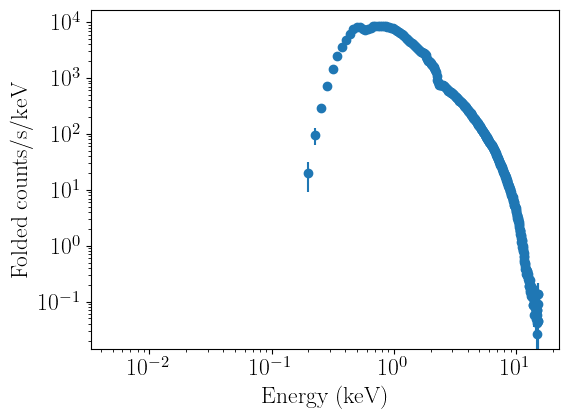

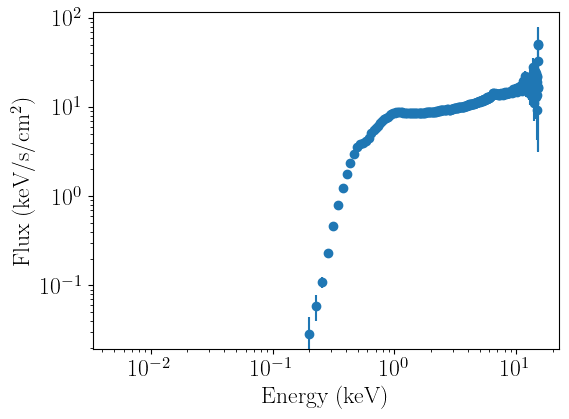

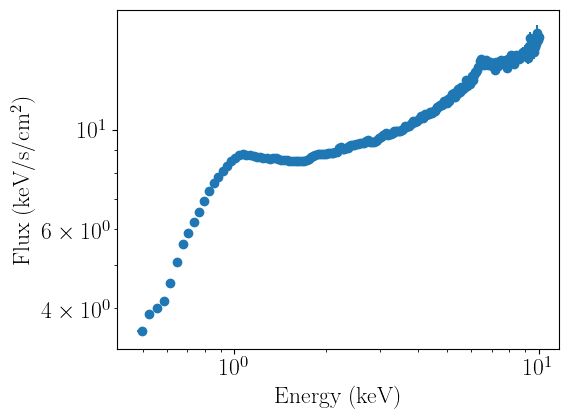

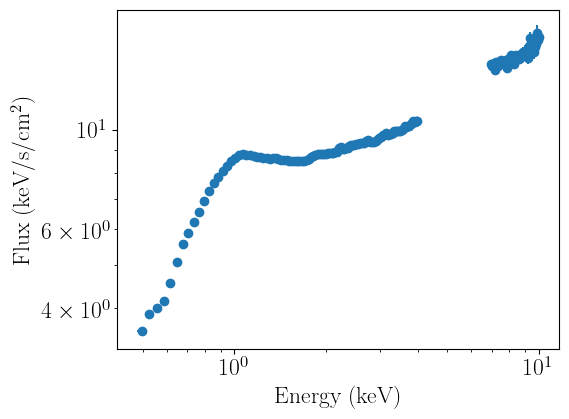

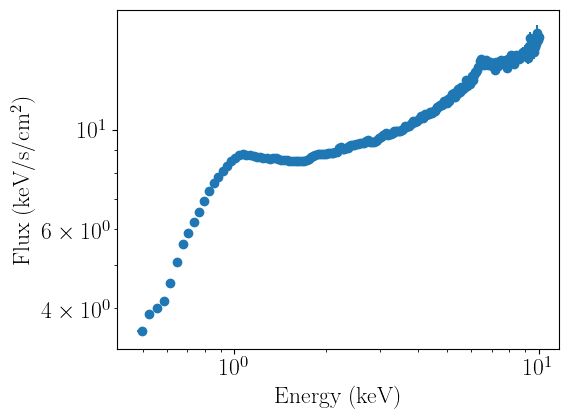

In [3]:
spectrum_fit.plot_data(units='data')
spectrum_fit.plot_data(units='eeunfold')
spectrum_fit.ignore_energies(0,0.5)
spectrum_fit.ignore_energies(10.0,20.0)
spectrum_fit.plot_data(units='eeunfold')
spectrum_fit.ignore_energies(4.0,7.0)
spectrum_fit.plot_data(units='eeunfold')
spectrum_fit.notice_energies(4.0,7.0)
spectrum_fit.plot_data(units='eeunfold')

## Defining a model and preparing a fit

We can now define a model to fit our data. In this case, we are analyzing the hard state of an X-ray binary, so we will use a phenomenological model with a disk component, a corona/power-law component, and correct both for line-of-sight absorption.

nDspec allows users to access the Xspec library of models directly, either with an existing Heasoft installation, or with the [Xspectrampoline][https://github.com/nDspec/xspectrampoline] package. 

In [4]:
#the FortranInterface automatically looks for a Heasoft/Xspec trampoline installation
model_library = XSModels.FortranInterface()

#dummy calls to set up the models
def tbabs(ear, params):
    pass

def diskbb(ear, params):
    pass

def nthcomp(ear, params):
    pass

def reflect(ear,params,seed):
    pass

#this call actually loads the models in the library 
model_library.load_models({
    "diskbb": diskbb,
    "tbabs": tbabs,
    "nthcomp": nthcomp
})

model_library.print_model_info()

#finally, we can write a set of wrappers in order to evaluate each model; these will be called through LMFit
def ndspec_nthcomp(ear,Gamma,kT_e,kT_bb,norm_comp):
    #wfor nthcomp, set the input type and redshift to default
    par_array = np.array([Gamma,kT_e,kT_bb,1,0,norm_comp])
    model = model_library.nthcomp(ear,par_array)
    return model

def ndspec_tbabs(ear,nH):
    par_array = np.array([nH])
    model = model_library.tbabs(ear,par_array)
    return model

def ndspec_diskbb(ear,Tin,norm_disk):
    #we actually take the log10 of the disk normalization for convenience
    norm_disk = 10**norm_disk
    par_array = np.array([Tin,norm_disk])
    model = model_library.diskbb(ear,par_array)
    return model


Initialized Xspec models:
diskbb:
  type: add
  function called: xsdskb
  parameters:
    Tin: value: 1.0, min: 0.0, max: 1000.0, unit: keV
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

tbabs:
  type: mul
  function called: C_tbabs
  parameters:
    nH: value: 1.0, min: 0.0, max: 1000000.0, unit: 10^22

nthcomp:
  type: add
  function called: C_nthcomp
  parameters:
    Gamma: value: 1.7, min: 1.001, max: 10.0, unit: n/a
    kT_e: value: 100.0, min: 1.0, max: 1000.0, unit: keV
    kT_bb: value: 0.1, min: 0.001, max: 10.0, unit: keV
    inp_type: value: 0.0, min: 0.0, max: 1.0, unit: 0/1
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    norm: value: 1, min: 0, max: 1e+20, unit: n/a

 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996


After defining the model functions, we can create an lmfit `Model` object using the standard synthax from other X-ray modelling softwares, ie absorption*(disk+powerlaw). We then initialize the parameter values using the `make_params` method of lmfit `Model` objects - here, `Gamma` is the Comptonization photon index, `norm_comp` the Comptonization normalization, `kT_e` the electron temperature, `kT_bb` the seed temperature in the Comptonization spectrum, `Tin` the diskbb temperature, `norm_disk` the diskbb normalization, and `nH` the absorbing column density. `make_params` returns an lmfit `Parameters` object, which can then be assigned to our fitter.

Once the model and its starting parameters are defined, we can assign them to our fitter object with the `set_model` method. Then, after the data, model, and initial parameters are loaded, we can use the `pretty_print` and `print_fit_stat` method to get an idea on the fit statistics for our current set of parameters.

In [5]:
from lmfit import Model as LM_Model

#define my unfolded model - this will be the only thing users have to define
unfolded_model = LM_Model(ndspec_tbabs)*(LM_Model(ndspec_nthcomp)+LM_Model(ndspec_diskbb))

start_params = unfolded_model.make_params(Gamma=dict(value=1.65,min=1.1,max=4.0),
                                          kT_e=dict(value=100,min=50,max=150,vary=False),
                                          kT_bb=dict(value=0.25,min=0.10,max=1),
                                          norm_comp=dict(value=6.5,min=1e-1,max=50.),
                                          Tin=dict(value=0.25,min=0.10,max=1,expr="1.0*kT_bb"),
                                          norm_disk=dict(value=5,min=-2,max=8),
                                          nH=dict(value=0.1,min=1e-3,max=2))

spectrum_fit.set_model(unfolded_model,params=start_params)
spectrum_fit.model_params.pretty_print()
spectrum_fit.print_fit_stat()

Name          Value      Min      Max   Stderr     Vary     Expr Brute_Step
Gamma          1.65      1.1        4     None     True     None     None
Tin            0.25      0.1        1     None    False 1.0*kT_bb     None
kT_bb          0.25      0.1        1     None     True     None     None
kT_e            100       50      150     None    False     None     None
nH              0.1    0.001        2     None     True     None     None
norm_comp       6.5      0.1       50     None     True     None     None
norm_disk         5       -2        8     None     True     None     None
Goodness of fit metrics:
Fit statistic: chisq
Fit statistic           7460.101968685523
Reduced fit stat        32.435225950806625
Data bins:              235
Free parameters:        5
Degrees of freedom:     230


tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.


Plotting the model and data together can be done with the `plot_model` method. Identically to `plot_data`, users can use both folded and model-independent unfolded units:

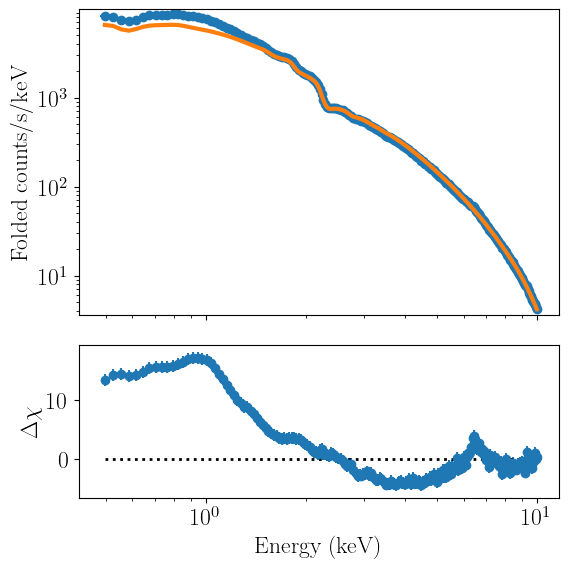

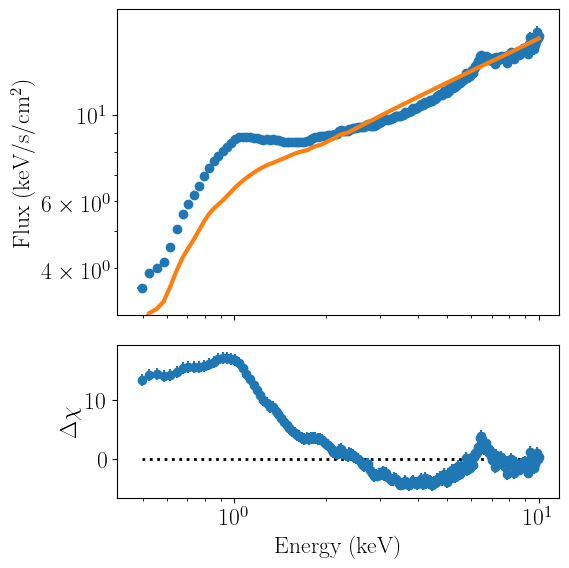

In [6]:
spectrum_fit.plot_model(units='data')
spectrum_fit.plot_model(units='eeunfold')

## Running a fit

We can now fit the data by minimizing the least-chi squares statistic with the `fit_data` method. Once the fit completes, the method will output the best-fit statistics and their corresponding parameter values:

In [7]:
spectrum_fit.fit_data()

-----------------------
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 55
    # data points      = 235
    # variables        = 5
    fit statistic      = 528.0203696134593
    reduced statistic  = 2.295740737449823
    Akaike info crit   = 200.2440966933623
    Bayesian info crit = 217.5420242640831
[[Parameters]]
    nH:         0.11679821 +/- 0.00784816 (6.72%) (init = 0.1), model_value = 0.1167982
    Gamma:      1.62134197 +/- 0.01872375 (1.15%) (init = 1.65), model_value = 1.621342
    kT_e:       100 (fixed)
    kT_bb:      0.27531342 +/- 0.00925560 (3.36%) (init = 0.25), model_value = 0.2753134
    norm_comp:  5.94249999 +/- 0.17148786 (2.89%) (init = 6.5), model_value = 5.9425
    Tin:        0.27531342 +/- 0.00925560 (3.36%) == '1.0*kT_bb'
    norm_disk:  5.22547140 +/- 0.07958545 (1.52%) (init = 5), model_value = 5.225471


/home/matteo/.local/lib/python3.8/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


It is extremely important to note that the error bars reported by these least-chi squares are often highly misleading, particularly for cases with relatively complex parameter spaces (as is the case for high signal/noise X-ray spectra). These intervals should only be used as a rough indication of how well parameters can be constrained. They should NOT be included in peer-reviewed research as credible parameter intervals. Instead, users are highly encouraged to use and report credible intervals from Bayesian sampling; the tutorial on [fitting power spectra](https://ndspec.readthedocs.io/en/latest/fit_psd.html) discusses how to do this in nDspec.

Once the fit is complete, we can plot the best-fitting model together with its components. Not that multiplicative components (such as tbabs) will not display correctly with the current implementation of nDspec. As a result, the automated plots from `plot_model` may not be good enough to be included in a scientific publication. This will be improved in a future version. Regardless, the relevant arrays (e.g. model values, data points, etc) are all accessible outside of the class. Users can find more information on the arrays required to create their own plots in the [nDspec API documentation page](https://ndspec.readthedocs.io/en/latest/api.html#ndspec.FitTimeAvgSpectrum.FitTimeAvgSpectrum).

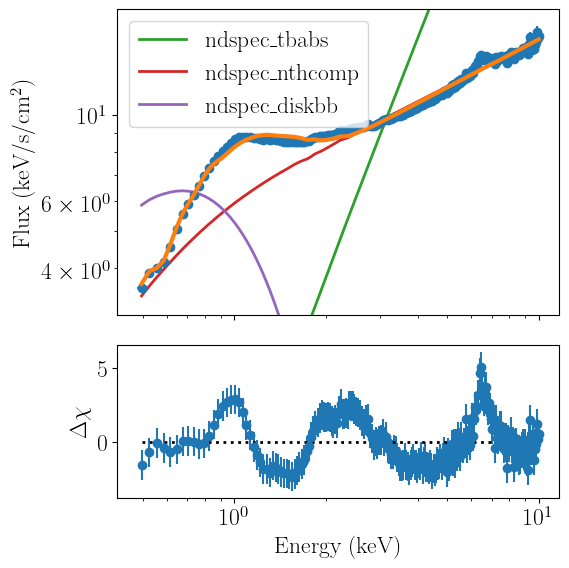

In [8]:
spectrum_fit.plot_model(units='eeunfold',plot_components=True)

Having run our fit and plotted our results, we can conclude that this spectrum shows the typical features of an accreting black hole in the hard state: the disk is relatively weak and only contributes below 1 keV, much of the total luminosity is emitted by the power-law component, and the residuals show clear reflection features.